### **1. Contexto**

El fraude en transacciones con tarjeta de crédito es uno de los principales peligros para las entidades financieras a nivel mundial, por lo que poder detectarlo a tiempo es importante para reducir las pérdidas económicas, proteger a los clientes y mantener la confianza en los sistemas de pago electrónico. Una de las principales características que dificultan la detección del fraude es que es muy poco frecuente en comparación con las transacciones no fraudulentas, por lo que hay un problema de desbalance de clases, en el sentido de que la clase minoritaria puede estar subrepresentada y esto puede afectar el análisis exploratorio y el rendimiento de los modelos de predicción. El presente trabajo usa el dataset Credit Card Fraud Detection, disponible en el Kaggle, el cual contiene transacciones reales realizadas por los titulares de tarjetas de crédito europeos durante septiembre de 2013.

### **2. Objetivos**

#### **2.1 Objetivo general**

El objetivo general de este EDA, es analizar el dataset de transacciones con tarjeta de crédito, comprender su estructura, explorar el desbalanceo de la variable respuesta y patrones importantes que nos ayuden para un futuro proceso de selección de variables y modelos adecuados para la detección de fraude.

#### **2.2 Objetivos específicos**

1. Describir la estructura general del dataset.
2. Evaluar el desbalance de la variable respuesta Class.
3. Analizar la distribución de las variables numéricas usando estadísticas descriptivas y visualizaciones.
4. Comparar las características de las transacciones fraudulentas y no fraudulentas.
5. Identificar posibles patrones asociados al fraude.
6. Detectar posibles relaciones entre variables mediante análisis de correlación.
7. Generar conclusiones que ayuden a la selección de variables y modelos predictivos.

### **3. Descripción del conjunto de datos**

El conjunto de datos utilizado corresponde al dataset Credit Card Fraud Detection, disponible públicamente en Kaggle (https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud). El dataset contiene transacciones realizadas por titulares de tarjetas de crédito europeos durante dos días en septiembre de 2013, con la finalidad de investigar la detección de fraude. 

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Math
from scipy.stats import mannwhitneyu
import pingouin as pg
import warnings
warnings.filterwarnings("ignore")
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
df = pd.read_csv(r"C:\Users\Alejandra\Desktop\datavis_py\data\creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape

(284807, 31)

In [4]:
columns= df.columns
columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

***Información de atributos (por orden)***:

**Numéricas**

- **Time**: Tiempo en segundos transcurridos entre esta transacción y la primera transacción en el dataset .

- **V1 – V28**: Componentes principales obtenidos mediante Análisis de Componentes Principales (PCA) para proteger la confidencialidad de las variables originales.

- **Amount**: Monto de la transacción.

**Categóricas**

- **Class**: Variable respuesta (1 = fraude, 0 = no fraude).

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Se observa que se está interpretando **Class** como númerica a pesar de ser categórica, por lo que se hace la debida transformación.

In [6]:
df['Class'] = df['Class'].astype(str)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

**Tabla de operacionalización de variables**

In [7]:
descripcion_variables = pd.DataFrame({
    "Variable": [
        "Time",
        "V1 – V28",
        "Amount",
        "Class"
    ],
    "Definición": [
        "Tiempo en segundos transcurridos desde la primera transacción del dataset.",
        "Componentes principales obtenidas mediante PCA para anonimizar las variables originales.",
        "Monto de la transacción.",
        "Indicador de fraude (1 = fraude, 0 = no fraude)."
    ],
    "Naturaleza": [
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Cualitativa"
    ],
    "Nivel_de_Medición": [
        "De razón",
        "De intervalo",
        "De razón",
        "Nominal dicotómica"
    ],
    "Criterio_Clasificación": [
        "Valor numérico ≥ 0 medido en segundos.",
        "Valores reales centrados obtenidos por combinación lineal.",
        "Valor numérico ≥ 0 expresado en unidades monetarias.",
        "Variable binaria (0 = no fraude, 1 = fraude)."
    ]
})

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

descripcion_variables

,Variable,Definición,Naturaleza,Nivel_de_Medición,Criterio_Clasificación
0,Time,Tiempo en segundos transcurridos desde la primera transacción del dataset.,Cuantitativa continua,De razón,Valor numérico ≥ 0 medido en segundos.
1,V1 – V28,Componentes principales obtenidas mediante PCA para anonimizar las variables originales.,Cuantitativa continua,De intervalo,Valores reales centrados obtenidos por combinación lineal.
2,Amount,Monto de la transacción.,Cuantitativa continua,De razón,Valor numérico ≥ 0 expresado en unidades monetarias.
3,Class,"Indicador de fraude (1 = fraude, 0 = no fraude).",Cualitativa,Nominal dicotómica,"Variable binaria (0 = no fraude, 1 = fraude)."


### **4. Limpieza y preparación de datos**

**Comprobación de duplicados**

In [8]:
#Número de filas duplicadas
df.duplicated().sum()

1081

Observamos que hay 1081 filas duplicadas, procedemos a eliminarlas:

In [9]:
# Eliminar filas duplicadas
df = df.drop_duplicates()
df.duplicated().sum()

0

Como podemos observar ya no hay filas duplicadas, se eliminaron exitosamente.

**Conteo de datos faltantes y porcentaje**

In [10]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [11]:
df.isnull().sum().sum()

0

Es decir, no tenemos Na's o datos faltantes.

### **5. Analisis Exploratorio de Datos (EDA)**

#### **5.1 Análisis univariado**

In [12]:
def resumen(variable):
    return {
        "mean": variable.mean(),
        "sd": variable.std(),
        "median": variable.median(),
        "IQR": variable.quantile(0.75) - variable.quantile(0.25),
        "min": variable.min(),
        "max": variable.max(),
        "Q1": variable.quantile(0.25),
        "Q3": variable.quantile(0.75),
    }

**Variable Class**

,Frecuencia,Proporción
Class,,
0,283253,99.83329
1,473,0.16671


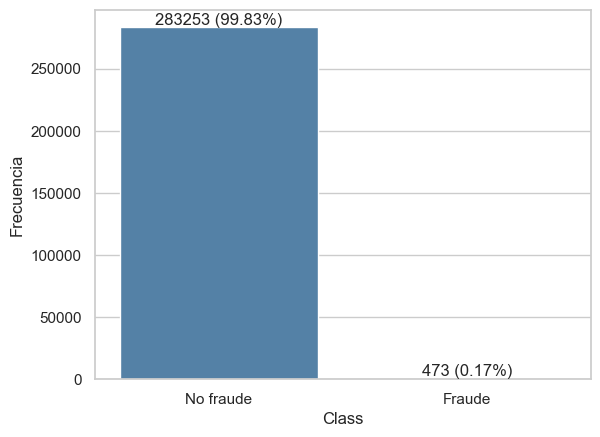

In [13]:
Frecuencia = df['Class'].value_counts()
proporciones = df['Class'].value_counts(normalize=True)*100
# Combinar los resultados en un solo DataFrame
resultado = pd.DataFrame({
    'Frecuencia': Frecuencia,
    'Proporción': proporciones
})
display(resultado)


sns.set(style="whitegrid")
ax = sns.countplot(x="Class", data=df, color="steelblue")
for i, p in enumerate(ax.patches):
    percentage = proporciones.iloc[i]
    count = int(p.get_height())
    ax.annotate(f'{count} ({percentage:.2f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

ax.set_xticklabels(["No fraude", "Fraude"])
plt.ylabel("Frecuencia")
plt.show()

Se observa un desbalance extremo en la variable respuesta Class, pues con un total de 283.726 transacciones, 283.253 (99.83%) corresponden a transacciones no fraudulentas (Clase 0) y 473 (0.17%) corresponden a transacciones fraudulentas (Clase 1).

**Variable Time**

In [14]:
time_uni = resumen(df["Time"]) 
tablatime_uni = pd.DataFrame({
    "Variable": ["Time"],
    "Media (SD)": [f'{time_uni["mean"]:.2f} ({time_uni["sd"]:.2f})'],
    "Mediana (IQR)": [f'{time_uni["median"]:.2f} ({time_uni["IQR"]:.2f})'],
    "Min": time_uni["min"],
    "Max": time_uni["max"],
    "Q1": time_uni["Q1"],
    "Q3": time_uni["Q3"]
})
tablatime_uni

,Variable,Media (SD),Mediana (IQR),Min,Max,Q1,Q3
0,Time,94811.08 (47481.05),84692.50 (85093.25),0.0,172792.0,54204.75,139298.0


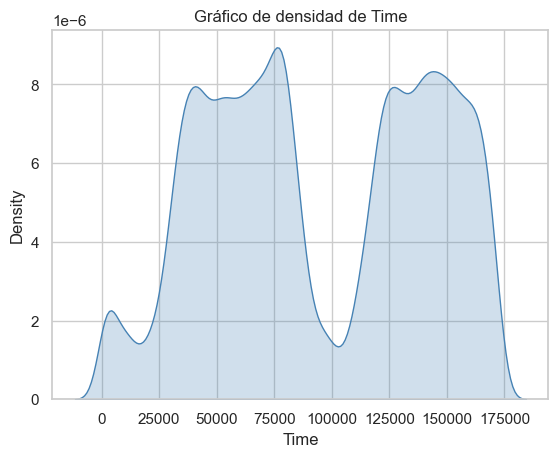

In [15]:
sns.set(style="whitegrid")
plt.title("Gráfico de densidad de Time")
sns.kdeplot(df["Time"], shade=True, color="steelblue")
plt.show()

Se evidencia que la variable Time tiene un promedio de 94811.08 segundos (desviación estándar de 47,481.05 segundos), lo que muestra una gran dispersión temporal a lo largo del periodo del análisis. La mediana es de 84692.50 segundos con un IQR de 85093.25 segundos, esto indica que el 50% de las transacciones ocurre entre 54204.75 y 139298.0 segundos aproximadamente desde el inicio del periodo. Realmente, el rango va de 0.0 a 172792.0 segundos, que es el intervalo total de los dos días analizados, no representan necesariamente valores atípicos, sino los límites del tiempo de obersvación. Por otro lado, en el gráfico de densidad se evidencia una distribución aproximadamente simétrica. Por otro lado, en el gráfico se oberva que hay una cierta concentración relativa en las transacciones al inicio y al final del intervalo temporal, con una menor densidad en la parte intermedia, que puede representar el final del primer día. Del mismo modo, en la gráfica se observa una distribución más plana con colas más ligeras que una normal, por lo que los tiempos se distribuyen de manera relativamente homogénea a lo largo de los dos días. En conclusión, aunque la dispersión es alta por la naturaleza de la escala temporal, la distribución no tiene colas pesadas ni sesgos relevantes.

**Variable Amount**

In [16]:
result = pd.DataFrame({
    'Media': [df["Amount"].mean()],
    'Desv. Estándar': [df["Amount"].std()],
    'Mínimo': [df["Amount"].min()],
    'Máximo': [df["Amount"].max()],
    'Mediana': [df["Amount"].median()],
    'Cuantil 1': [df["Amount"].quantile(0.25)],
    'Cuantil 3': [df["Amount"].quantile(0.75)],
    'IQR': [df["Amount"].quantile(0.75) - df["Amount"].quantile(0.25)]
})

result

,Media,Desv. Estándar,Mínimo,Máximo,Mediana,Cuantil 1,Cuantil 3,IQR
0,88.472687,250.399437,0.0,25691.16,22.0,5.6,77.51,71.91


La cantidad promedio transferido fue de 88.47 (desviación estándar de 250.39 euros), con un rango de 0 a 25691.16, lo que indica que se hicieron transacciones con valores muy bajos y otros muy altos. El 50% de las transacciones realizadas estuvieron por debajo de 22 euros, con un rango intercuartílico de 71.91. Por otro lado, el monto del 25% de las transacciones fue menor o igual a 5.60 euros, mientras que el 75% estuvo por debajo de 77.51. 

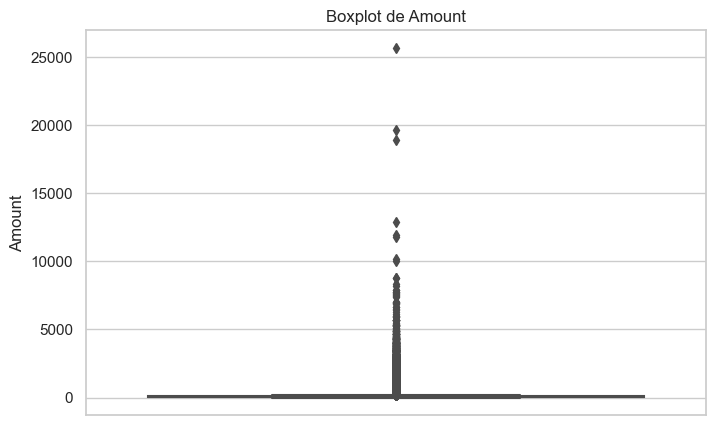

In [17]:
# Boxplot de amount
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['Amount'])
plt.title('Boxplot de Amount')
plt.show()

De acuerdo con el boxplot de la variable `Amount`, se evidencia una fuerte asímetria positiva, con una alta concentración de valores en montos bajos y una cola larga hacia valores elevados. Se observan múltiples valores extremos, lo cual sugiere una distribución altamente sesgada.

**Variables V1,...,V28**

In [18]:
# Seleccionamos todas las PCs 
pc_df = df.loc[:, "V1":"V28"]

lista = []
for col in pc_df.columns:
    dic = {
        "Variable": col,
        "Media (SD)": f"{resumen(pc_df[col])['mean']:.2f} ({resumen(pc_df[col])['sd']:.2f})",
        "Mediana (IQR)": f"{resumen(pc_df[col])['median']:.2f} ({resumen(pc_df[col])['IQR']:.2f})",
        "Min": resumen(pc_df[col])['min'],
        "Max": resumen(pc_df[col])['max'],
        "Q1": resumen(pc_df[col])['Q1'],
        "Q3": resumen(pc_df[col])['Q3']
    }
    lista.append(dic)

tabla_pcs = pd.DataFrame(lista)
tabla_pcs 


,Variable,Media (SD),Mediana (IQR),Min,Max,Q1,Q3
0,V1,0.01 (1.95),0.02 (2.23),-56.407510,2.454930,-0.915951,1.316068
1,V2,-0.00 (1.65),0.06 (1.40),-72.715728,22.057729,-0.600321,0.800283
2,V3,0.00 (1.51),0.18 (1.92),-48.325589,9.382558,-0.889682,1.026960
3,V4,-0.00 (1.41),-0.02 (1.59),-5.683171,16.875344,-0.850134,0.739647
4,V5,0.00 (1.38),-0.05 (1.30),-113.743307,34.801666,-0.689830,0.612218
5,V6,-0.00 (1.33),-0.28 (1.17),-26.160506,73.301626,-0.769031,0.396792
6,V7,0.00 (1.23),0.04 (1.12),-43.557242,120.589494,-0.552509,0.570474
7,V8,-0.00 (1.18),0.02 (0.53),-73.216718,20.007208,-0.208828,0.325704
8,V9,-0.00 (1.10),-0.05 (1.24),-13.434066,15.594995,-0.644221,0.595977
9,V10,-0.00 (1.08),-0.09 (0.99),-24.588262,23.745136,-0.535578,0.453619


Es importante recordar que estas variables corresponden a las componentes principales obtenidas mediante Análisis de Componentes Principales (PCA), la cual es una técnica que transforma un conjunto de variables correlacionadas en un nuevo conjunto de componentes ortogonales ordenadas según la varianza que explican. Como resultado de este proceso, todas las componentes se encuentran centradas alrededor de cero, lo que explica que tanto las **medias** como las **medianas** sean cercanas a este valor. Un aspecto importante y evidente es el patrón decreciente de la **desviación estándar**, que pasa de aproximadamente 1.95 en V1 a 0.33 en V28. Esto es característico del PCA, ya que las primeras componentes concentran una mayor proporción de la varianza total del conjunto original, mientras que las posteriores describen variaciones cada vez menores del espacio de datos; sin embargo, esto no se traduce en mayor importancia predictiva. 

El **rango intercuartílico (IQR)** también muestra un descenso general conforme se avanza hacia las últimas componentes, lo cual es coherente con la reducción de varianza observada en la desviación estándar. No obstante, algunas componentes intermedias presentan rangos intercuartílicos ligeramente altos a la anterior, dado que esta medida refleja la dispersión del 50% central de los datos y no necesariamente sigue de manera estricta el mismo patrón que la varianza total, pues las colas pesadas o asimetrías pueden afectar. No obstante, en términos generales las variables que tienen mayor dispersión con respecto a la mediana son **V1 (IQR = 2.23)**, la cual captura la mayor variabilidad de los datos, V3, V4, V11, V2, V13, V5, V9, que siguen siendo parte de la primera mitad de las componentes.

En cuanto a los **valores mínimos y máximos**, se observan extremos bastante amplios en algunas de las primeras componentes (por ejemplo, V2, V5, V7 y V8). Estos valores representan observaciones situadas en posiciones extremas dentro de la dirección definida por cada componente, es decir son datos atípicos en el dataset transformado, pero no necesariamente en el original, pero la combinaciones de los datos originales dieron generaron este comportamiento. La presencia de estos extremos contribuye a que la desviación estándar sea considerablemente mayor que el IQR en varias variables, como las previamente mencionadas, lo que sugiere colas pesadas y una concentración de dispersión en pocos casos extremos más que en la variabilidad central.

Es decir, a pesar que las primeras componentes (aproximadamente V1–V4) concentran la mayor parte de la dispersión global del espacio transformado, la forma de las distribuciones y la presencia de valores extremos no desaparecen necesariamente en las componentes finales, cómo veremos a continuación.

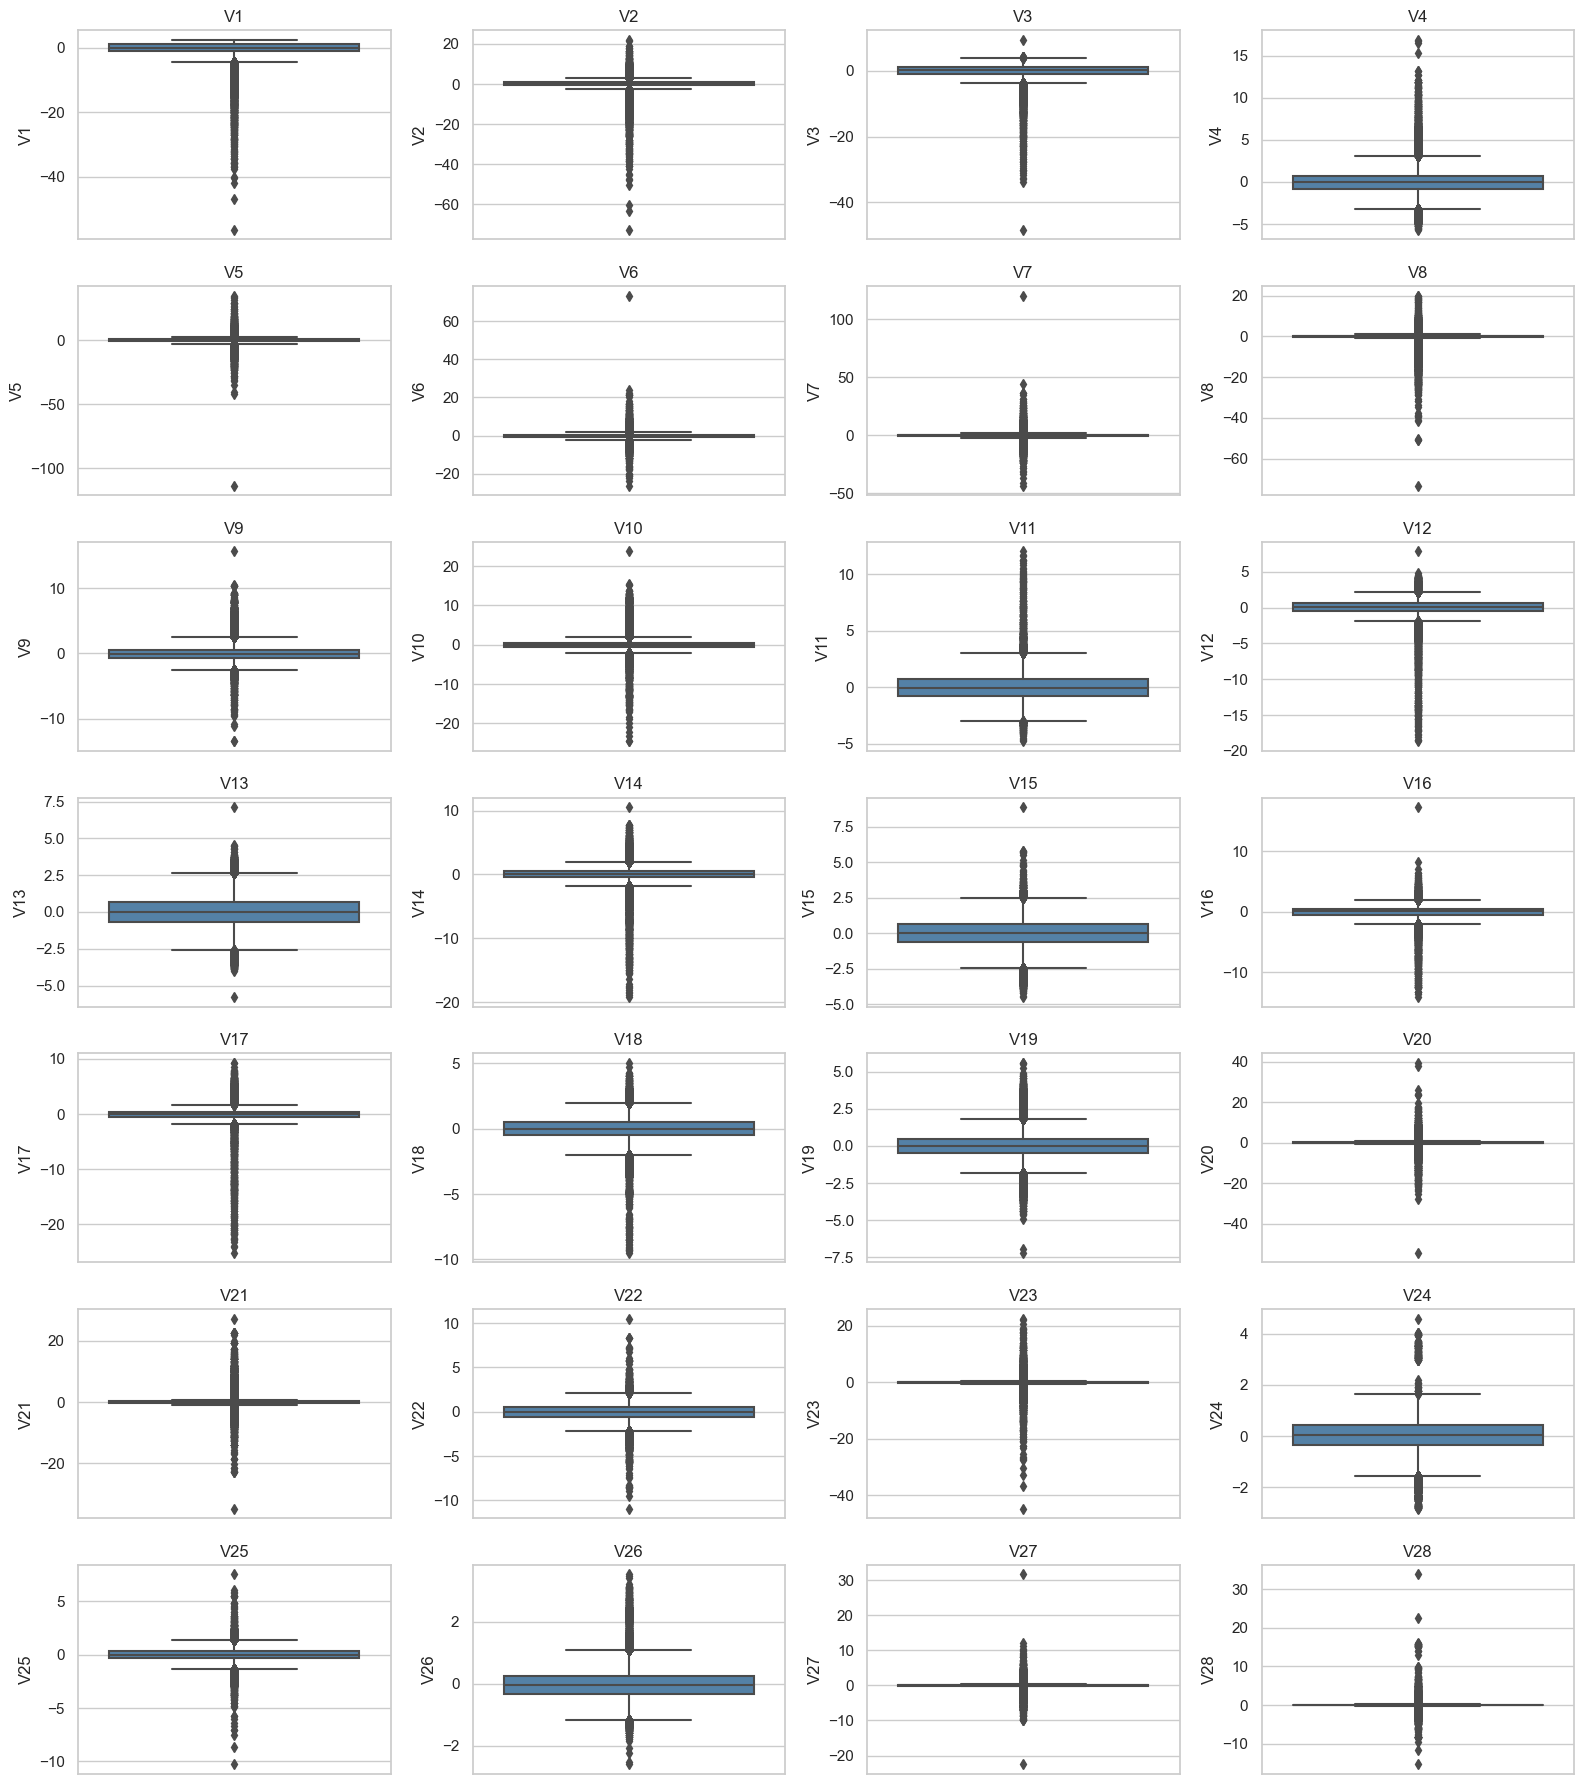

In [19]:

plt.figure(figsize=(16, 18))
for i, col in enumerate(pc_df.columns):
    plt.subplot(7, 4, i+1)  # 7 filas, 4 columnas = 28 espacios
    sns.boxplot(y=df[col], color='steelblue')
    plt.title(col)
    plt.xticks([])
    plt.tight_layout()

plt.show()

Gracias al gran número de observaciones y la presencia de colas pesadas en varias variables, los diagramas de cajas y bigotes muestran una alta concentración de los valores atípicos, lo que dificulta la interpretación visual de la simetría. Por esto, se calculan los coeficientes de asimetría y curtosis para evaluar de manera cuantitativa la forma de las distribuciones a continuación.

In [20]:
# Creamos lista para ir guardando los resultados 
stats_list = []
for col in columns[1:29]: 
    stats_list.append({
        "Variable": col,
        "Skew": round(df[col].skew(), 2),
        "Kurtosis": round(df[col].kurtosis(), 2)
    })


stats_df = pd.DataFrame(stats_list)
stats_df

,Variable,Skew,Kurtosis
0,V1,-3.27,32.73
1,V2,-4.70,96.90
2,V3,-2.15,25.19
3,V4,0.67,2.62
4,V5,-2.41,209.28
5,V6,1.83,42.84
6,V7,2.89,414.14
7,V8,-8.31,215.02
8,V9,0.54,3.52
9,V10,1.25,29.84


En primer lugar, en los **boxplots** de las variables se observa un patrón que concuerda con lo dicho previamente de la varianza del conjunto de datos. Las primeras variables (V1, V2, V3) muestran una mayor dispersión visual y una presencia más marcada de valores extremos que generan una asimetría a la izquierda, lo cual indica que gran parte de la variabilidad proyectada en estas direcciones se concentra en valores alejados del centro. Siguiendo este orden de ideas, conforme se avanza a variables componentes posteriores, la dispersión general disminuye, lo cual es consistente con la naturaleza del PCA. En estas variables posteriores, los valores atípicos tienden a distribuirse de manera más balanceada entre ambos extremos o a concentrarse menos intensamente en una sola dirección, reflejando distribuciones más centradas alrededor de cero.

La **asimetría (skewness)** confirma estos patrones. V1, V2 y V3 presentan asimetría negativa fuerte, mientras que V4 presenta asimetría positiva, lo que indica colas extendidas en direcciones opuestas. Otras variables intermedias como V6, V7, V10 y V21 muestran asimetría positiva, mientras que V5, V8, V17, V20 y V23 presentan asimetría negativa. Esto evidencia que los extremos no se concentran sistemáticamente en una sola dirección a lo largo de las componentes, sino que dependen de la estructura específica capturada por cada una. Algunas variables como V11, V13, V15, V18, V19 y V22 presentan valores de skew cercanos a cero, lo que indica distribuciones aproximadamente simétricas. En el caso de V28, el skew elevado es indicio de una cola derecha pronunciada, posiblemente influenciada por observaciones extremas visibles en el boxplot. Sin embargo, dado que esta componente explica una proporción menor de la varianza total, su impacto estructural global es limitado.

Por otro lado, en el **apuntamiento (Kurtosis)** los valores superiores a 3 indican distribuciones leptocúrticas que se caracterizan por colas pesadas y una mayor presencia de valores extremos. Variables como V1, V2, V5, V7, V8, V20, V21, V23 y V28 tienen kurtosis muy alta, lo que confirma las colas pesadas generadas por la gran cantidad de outliers observadas en los boxplots y contribuye a que la desviación estándar sea relativamente mayor en comparación con el rango intercuartílico. En cambio, variables como V11, V13, V15, V18, V19 tienen kurtosis más moderadas, lo que representa distribuciones mesocúrticas, es decir más planas y con menos valores extremos.

En conjunto, las primeras componentes no solo concentran mayor varianza, sino que también exhiben mayor asimetría y colas más pesadas, lo que refleja que las direcciones principales de variabilidad presentan proyecciones con extremos marcados. Las componentes posteriores capturan variaciones más sutiles y presentan, en general, menor dispersión y menor intensidad en los extremos, lo cual es consistente con la lógica del PCA.


#### **5.2 Análisis bivariado**

Con el fin de evaluar diferencias entre las transacciones fraudulentas y no fraudulentas en las variables numéricas continuas, se empleó la prueba no paramétrica de Mann-Withney U, pues permite ver si hay diferencias en la distribución de una variable entre dos grupos independientes sin asumir normalidad ni homogeneidad de varianzas. Además, resulta apropiado y aporta robustez al análisis, pues como se observó en el análisi univariado previo, la mayoría de las variables presentan una fuerte asimetría y valores extremos que generan colas pesadas.

**Time vs Class**

In [51]:
fraude = df[df["Class"] == "1"]
no_fraude = df[df["Class"] == "0"]

def resumen(variable):
    return {
        "n": variable.count(),
        "mean": variable.mean(),
        "sd": variable.std(),
        "median": variable.median(),
        "IQR": variable.quantile(0.75) - variable.quantile(0.25),
        "min": variable.min(),
        "max": variable.max(),
        "Q1": variable.quantile(0.25),
        "Q3": variable.quantile(0.75),
    }
    

def tabla_comparacion(df, variable):
    
    res1 = resumen(fraude[variable])
    res2 = resumen(no_fraude[variable])
    # t-test
    g1 = fraude[variable]
    g2 = no_fraude[variable]
    
   #calculamos el Mann-Whitney U test y el tamaño de efecto tambien viene dentro
    res = pg.mwu(g1, g2, alternative='two-sided')
    u_stat = res["U-val"].values[0]
    pvalue = res["p-val"].values[0]
    rbc = res["RBC"].values[0]
    
    # Crear tabla
    tabla = pd.DataFrame({
        "Grupo": ["Fraude", "No fraude"],
        "n": [res1["n"], res2["n"]],
        "Media (SD)": [
            f'{res1["mean"]:.2f} ({res1["sd"]:.2f})',
            f'{res2["mean"]:.2f} ({res2["sd"]:.2f})'
        ],
        "Mediana (IQR)": [
            f'{res1["median"]:.2f} ({res1["IQR"]:.2f})',
            f'{res2["median"]:.2f} ({res2["IQR"]:.2f})'
        ],
        "Min–Max": [
            f'{res1["min"]:.2f}–{res1["max"]:.2f}',
            f'{res2["min"]:.2f}–{res2["max"]:.2f}'
        ],
        "Q1": [res1["Q1"], res2["Q1"]],
        "Q3": [res1["Q3"], res2["Q3"]],
        "U": [round(u_stat, 3), ""],
        "p": [f"{pvalue:.3e}", ""],
        "RBC": [f"{rbc:.3f}", ""]
    })
    
    return tabla

,Grupo,n,Media (SD),Mediana (IQR),Min–Max,Q1,Q3,U,p,RBC
0,Fraude,473,80450.51 (48636.18),73408.00 (87892.00),406.00–170348.00,41203.0,129095.0,55697454.0,2.233e-10,-0.169
1,No fraude,283253,94835.06 (47475.55),84711.00 (85075.00),0.00–172792.00,54233.0,139308.0,,,


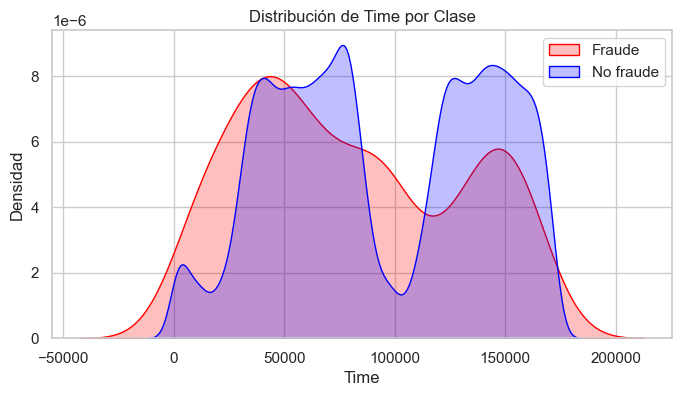

In [52]:
display(tabla_comparacion(df, "Time"))

plt.figure(figsize=(8,4))
sns.kdeplot(fraude["Time"], label="Fraude", color="red", fill=True)
sns.kdeplot(no_fraude["Time"], label="No fraude", color="blue", fill=True)
plt.title("Distribución de Time por Clase")
plt.xlabel("Time")
plt.ylabel("Densidad")
plt.legend()
plt.show()




Las transacciones fraudulentas (n = 473) ocurren en un tiempo promedio de 80,450.51 segundos desde la primera transacción (desviación estándar de 48,636.18 segundos). La mediana es de 73,408 segundos (IQR = 87,892 segundos), lo que indica que el 50% de las transacciones fraudulentas se concentra entre 41,203 y 129,095 segundos aproximadamente. El mínimo fue de 406 segundos y el máximo de 170,348 segundos, lo que evidencia que los fraudes se distribuyen a lo largo de casi todo el periodo de observación.

Las transacciones no fraudulentas (n = 283,253) presentan un tiempo promedio mayor (94,835.06 segundos con desviación estándar de 47,475.55 segundos), con una mediana de 84,711 segundos (IQR = 85,750 segundos). Luego, el 50% de estas transacciones se ubica entre 54,233 y 139,308 segundos. El rango completo va de 0 a 172,792 segundos, cubriendo todo el periodo analizado. Además, como se evidencia en el gráfico de densidad y de forma similar a lo observado previamente en la distribución sin clasificación, existe una mayor concentración relativa de transacciones al inicio y al final del intervalo temporal, con menor densidad en la parte intermedia, posiblemente asociada al final del primer día, esto se debe al fuerte desbalance entre clases donde la distribución global del tiempo se ve principalmente determinada por las transacciones no fraudulentas.

Siguiendo este orden de ideas, las transacciones fraudulentas tienden a ocurrir un poco antes que las no fraudulentas, como lo reflejan la media y la mediana; sin embargo, ambas distribuciones tienen una gran dispersión y un solapamiento en prácticamente todo el intervalo temporal, lo que indica que el momento en el que ocurre la transacción no distingue de manera marcada entre fraude y no fraude. Esto es notorio, porque aunque la diferencia entre grupos resultó estadísticamente significativa (p < 0.05), el gran tamaño muestral puede hacer que diferencias pequeñas resulten estadísticamente significativas, por eso también se reporta el tamaño del efecto RBC = -0.169, el cual sugiere una magnitud práctica de la diferencia de pequeña.

**Variables V1,..,V28 vs Class**

In [55]:
grupo1 = []

def tabla_variable(df, variable):
    
    fraude = df[df["Class"] == "1"][variable]
    no_fraude = df[df["Class"] == "0"][variable]
    total = df[variable]
    
    def resumen(x):
        return {
            "n": x.count(),
            "mean": x.mean(),
            "sd": x.std(),
            "median": x.median(),
            "IQR": x.quantile(0.75) - x.quantile(0.25),
            "Q1": x.quantile(0.25),
            "Q3": x.quantile(0.75),
            "min": x.min(),
            "max": x.max(),
        }
        
    r_f = resumen(fraude)
    r_nf = resumen(no_fraude)
    r_t = resumen(total)
    
    
    #calculamos el Mann-Whitney U test y el tamaño de efecto tambien viene dentro
    res = pg.mwu(fraude, no_fraude, alternative='two-sided')
    u_stat = res["U-val"].values[0]
    pvalue = res["p-val"].values[0]
    rbc = res["RBC"].values[0]
    
    tabla = pd.DataFrame({
        "Variable": [variable, "", ""],
        "Grupo": ["Fraude", "No fraude", "Total"],
        "n": [r_f["n"], r_nf["n"], r_t["n"]],
        
        "Media (SD)": [
            f'{r_f["mean"]:.2f} ({r_f["sd"]:.2f})',
            f'{r_nf["mean"]:.2f} ({r_nf["sd"]:.2f})',
            f'{r_t["mean"]:.2f} ({r_t["sd"]:.2f})'
        ],
        
        "Mediana": [
            f'{r_f["median"]:.2f}',
            f'{r_nf["median"]:.2f}',
            f'{r_t["median"]:.2f}'
        ],
        
        "Q1": [
            f'{r_f["Q1"]:.2f}',
            f'{r_nf["Q1"]:.2f}',
            f'{r_t["Q1"]:.2f}'
        ],
        
        "Q3": [
            f'{r_f["Q3"]:.2f}',
            f'{r_nf["Q3"]:.2f}',
            f'{r_t["Q3"]:.2f}'
        ],
        
        "IQR": [
            f'{r_f["IQR"]:.2f}',
            f'{r_nf["IQR"]:.2f}',
            f'{r_t["IQR"]:.2f}'
        ],
        
        "Min–Max": [
            f'{r_f["min"]:.2f}–{r_f["max"]:.2f}',
            f'{r_nf["min"]:.2f}–{r_nf["max"]:.2f}',
            f'{r_t["min"]:.2f}–{r_t["max"]:.2f}'
        ],
        
        "U": [round(u_stat, 3), "", ""],
        "p": [f"{pvalue:.3e}", "", ""],
        "RBC": [f"{rbc:.3f}", "",""]
})
    
    return tabla


variables = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

variables.remove('Time')
variables.remove('Amount')

for var in variables:
    display(tabla_variable(df, var))

,Variable,Grupo,n,Media (SD),Mediana,Q1,Q3,IQR,Min–Max,U,p,RBC
0,V1,Fraude,473,-4.50 (6.59),-2.27,-5.60,-0.36,5.24,-30.55–2.13,28197486.0,2.571e-105,-0.579
1,,No fraude,283253,0.01 (1.92),0.02,-0.91,1.32,2.23,-56.41–2.45,,,
2,,Total,283726,0.01 (1.95),0.02,-0.92,1.32,2.23,-56.41–2.45,,,


,Variable,Grupo,n,Media (SD),Mediana,Q1,Q3,IQR,Min–Max,U,p,RBC
0,V2,Fraude,473,3.41 (4.12),2.62,1.15,4.57,3.43,-8.40–22.06,113855524.0,8.275e-153,0.700
1,,No fraude,283253,-0.01 (1.63),0.06,-0.60,0.80,1.40,-72.72–18.90,,,
2,,Total,283726,-0.00 (1.65),0.06,-0.60,0.80,1.40,-72.72–22.06,,,


,Variable,Grupo,n,Media (SD),Mediana,Q1,Q3,IQR,Min–Max,U,p,RBC
0,V3,Fraude,473,-6.73 (6.91),-4.88,-7.93,-2.17,5.76,-31.10–2.25,12240264.0,8.739e-208,-0.817
1,,No fraude,283253,0.01 (1.46),0.18,-0.88,1.03,1.91,-48.33–9.38,,,
2,,Total,283726,0.00 (1.51),0.18,-0.89,1.03,1.92,-48.33–9.38,,,


,Variable,Grupo,n,Media (SD),Mediana,Q1,Q3,IQR,Min–Max,U,p,RBC
0,V4,Fraude,473,4.47 (2.87),4.10,2.29,6.29,4.00,-1.31–12.11,125438246.0,1.599e-236,0.873
1,,No fraude,283253,-0.01 (1.40),-0.02,-0.85,0.73,1.59,-5.68–16.88,,,
2,,Total,283726,-0.00 (1.41),-0.02,-0.85,0.74,1.59,-5.68–16.88,,,


,Variable,Grupo,n,Media (SD),Mediana,Q1,Q3,IQR,Min–Max,U,p,RBC
0,V5,Fraude,473,-2.96 (5.28),-1.37,-4.28,0.26,4.54,-22.11–11.10,40179560.0,2.830e-51,-0.400
1,,No fraude,283253,0.01 (1.36),-0.05,-0.69,0.61,1.30,-113.74–34.80,,,
2,,Total,283726,0.00 (1.38),-0.05,-0.69,0.61,1.30,-113.74–34.80,,,


...

,Variable,Grupo,n,Media (SD),Mediana,Q1,Q3,IQR,Min–Max,U,p,RBC
0,V24,Fraude,473,-0.11 (0.52),-0.06,-0.44,0.28,0.72,-2.03–1.09,58362910.0,1.255e-06,-0.129
1,,No fraude,283253,0.00 (0.61),0.04,-0.35,0.44,0.79,-2.84–4.58,,,
2,,Total,283726,0.00 (0.61),0.04,-0.35,0.44,0.79,-2.84–4.58,,,


,Variable,Grupo,n,Media (SD),Mediana,Q1,Q3,IQR,Min–Max,U,p,RBC
0,V25,Fraude,473,0.04 (0.81),0.08,-0.32,0.46,0.78,-4.78–2.21,71299741.0,1.544e-02,0.064
1,,No fraude,283253,-0.00 (0.52),0.02,-0.32,0.35,0.67,-10.30–7.52,,,
2,,Total,283726,-0.00 (0.52),0.02,-0.32,0.35,0.67,-10.30–7.52,,,


,Variable,Grupo,n,Media (SD),Mediana,Q1,Q3,IQR,Min–Max,U,p,RBC
0,V26,Fraude,473,0.05 (0.46),0.01,-0.26,0.40,0.66,-1.15–2.75,72036301.0,4.573e-03,0.075
1,,No fraude,283253,0.00 (0.48),-0.05,-0.33,0.24,0.57,-2.60–3.52,,,
2,,Total,283726,0.00 (0.48),-0.05,-0.33,0.24,0.57,-2.60–3.52,,,


,Variable,Grupo,n,Media (SD),Mediana,Q1,Q3,IQR,Min–Max,U,p,RBC
0,V27,Fraude,473,0.21 (1.25),0.39,-0.02,0.82,0.84,-7.26–3.05,94018959.0,4.334e-52,0.403
1,,No fraude,283253,0.00 (0.39),0.00,-0.07,0.09,0.16,-22.57–31.61,,,
2,,Total,283726,0.00 (0.40),0.00,-0.07,0.09,0.16,-22.57–31.61,,,


,Variable,Grupo,n,Media (SD),Mediana,Q1,Q3,IQR,Min–Max,U,p,RBC
0,V28,Fraude,473,0.08 (0.53),0.15,-0.10,0.37,0.47,-1.87–1.78,86597204.0,3.174e-28,0.293
1,,No fraude,283253,0.00 (0.33),0.01,-0.05,0.08,0.13,-15.43–33.85,,,
2,,Total,283726,0.00 (0.33),0.01,-0.05,0.08,0.13,-15.43–33.85,,,


In [61]:
V = [col for col in df.columns if col.startswith('V')]

# clase fraude en componentes V1-V28
Fraude = (df[df["Class"] == "1"]).filter(col for col in df.columns if col.startswith('V'))

# clase No fraude en componentes V1-V28
No_Fraude = (df[df["Class"] == "0"]).filter(col for col in df.columns if col.startswith('V'))

# coeficiente de rbc
Coeficiente_rbc = [pg.mwu(Fraude[col], No_Fraude[col], alternative='two-sided')["RBC"].values[0] for col in V]

datos = {
    # obtenemos todas las componentes de V1 hasta V28
    'variables': V,
    
    # cuartiles del grupo fraude
    'Q1_F': Fraude.quantile(0.25),
    
    'Q3_F': Fraude.quantile(0.75),
    
    # cuartiles del grupo no fraude
    'Q1_NF': No_Fraude.quantile(0.25),
    
    'Q3_NF': No_Fraude.quantile(0.75),
    
    # coeficiente de cohen´s d
    'rbc': Coeficiente_rbc
}


Datos_DF = pd.DataFrame(datos)


# ahora, calculamos el indice de solapamiento
def indice_solapamiento(x):
    
    # calculamos los intervalos de fraude y no fraude
    q1_fraude, q3_fraude = x['Q1_F'], x['Q3_F']
    q1_nofraude, q3_nofraude = x['Q1_NF'], x['Q3_NF']
    
    # calculamos su intersección
    lim_inferior_i = max(q1_fraude, q1_nofraude)
    lim_superior_i = min(q3_fraude, q3_nofraude)
    
    # calculamos si hay solapamiento
    if lim_inferior_i < lim_superior_i:
        interseccion = lim_superior_i - lim_inferior_i # longitud de la intersección
    else:
        interseccion = 0 # no hay solapamiento.
        
    # calculamos su unión
    lim_inferior_u = min(q1_fraude, q1_nofraude)
    lim_superior_u = max(q3_fraude, q3_nofraude)
    
    # longitud de la unión
    union = lim_superior_u - lim_inferior_u 
    
    # calculamos indice o proporción
    if union > 0: # evitamos que se divida por 0.
        s = interseccion / union # ¿que fracción del total es común a ambos?
    else:
        s = 0
    
    return s # retornamos el indice.        
       
# aplica la función a cada fila del dataframe y la guarda en una nueva columna llamada 'S'                
Datos_DF['S'] = Datos_DF.apply(indice_solapamiento, axis=1)

# determina si hay solapamiento y la guarda en una nueva columna llamada 'Hay_Solapamiento'
Datos_DF['Hay_Solapamiento'] = Datos_DF['S'] > 0


# clasificación según criterios preestablecidos
def clasificacion_criterio(x):
    valor_abs_d = abs(x['rbc']) # calculamos valor absoluto coeficiente de Cohen
    indice_S = x['S'] # calcula los indices de S
    
     # condición grupo 1
    if valor_abs_d > 0.5  and indice_S == 0:
        return 1
    # condición grupo 2
    elif valor_abs_d >= 0.3:
        return 2
    # condición grupo 3
    else:
        return 3
    
Datos_DF['Grupo'] = Datos_DF.apply(clasificacion_criterio, axis=1)

print(Datos_DF[['variables', 'rbc', 'S', 'Hay_Solapamiento', 'Grupo']].to_string(index=False))

variables       rbc        S  Hay_Solapamiento  Grupo
       V1 -0.579075 0.079764              True      2
       V2  0.699607 0.000000             False      1
       V3 -0.817280 0.000000             False      1
       V4  0.872511 0.000000             False      1
       V5 -0.400210 0.193954              True      2
       V6 -0.537483 0.124256              True      2
       V7 -0.659248 0.000000             False      1
       V8  0.324727 0.253350              True      2
       V9 -0.682572 0.000000             False      1
      V10 -0.821164 0.000000             False      1
      V11  0.829646 0.000000             False      1
      V12 -0.868913 0.000000             False      1
      V13 -0.044037 0.783368              True      3
      V14 -0.894278 0.000000             False      1
      V15 -0.029466 0.943151              True      3
      V16 -0.682871 0.000000             False      1
      V17 -0.600945 0.000000             False      1
      V18 -0.466414 0.120897

Dado que son muchas variables, vamos a definir un criterio para clasificarlas según su capacidad discriminativa, y tener claro cuáles pueden llegar a explicar las clases de la variable objetivo. Este umbral va a estar ligado al solapamiento del 50% central (intervalo entre Q1 y Q3) y al tamaño del efecto estimado mediante la correlación biserial por rangos (RBC). Se dividirán en tres grupos:

- Alto poder discriminante: cuando los intervalos intercuartílicos no se solapan y el coeficiente rbc es |$r_{rb}$| > 0.5.

- Moderado poder discriminante: cuando el tamaño del efecto es moderado (0.3 <= |$r_{rb}$| <= 0.5), aunque los cuartiles puedan superponerse parcialmente.

- Bajo poder discriminante: cuando los cuartiles se solapan ampliamente y el tamaño del efecto es muy bajo (|$r_{rb}$| < 0.3).

**Componentes con alta diferencia entre clases**

Las componentes que presentan una mayor capacidad discriminativa fueron: `V2`, `V3`, `V4`, `V7`, `V9`, `V10`, `V11`, `V12`, `V14`, `V16` y `V17`. Los intervalos intercuartílicos no se superponen entre sí, indicando que el 50% central de los valores de fraude está completamente separado del 50% central de los no fraudes. El valor absoluto de la correlación biserial por rangos ($r_{rb}$) en todas las componentes es superior a 0.5, lo que indica un tamaño del efecto grande y una clara separación entre ambos grupos. Estas componentes son las que mejor discriminan entre fraude y no fraude, y constituyen las variables más prometedoras para la construcción del modelo predictivo.

**Componentes con diferencia moderada**

Las componentes `V1`, `V5`, `V6`, `V8`, `V18`, `V19`, `V20`, `V21`, `V14` y `V27` presentan un moderado poder discriminante. Es decir, los intervalos intercuartílicos se supornen de manera parcial o moderada, sugiriendo que del 50% central de los valores de fraude hay una zona de valores donde el 50% central de los datos de no fraude comparten casos típicos. Mientras tanto, El valor absoluto de la correlación biserial por rangos en algunas componentes es mayor o igual que 0.5, mientras que en otros esta bajo el umbral previamente establecido. Estas variables, no discriminan tan bien como las altas, sin embargo, pueden aportar información a la hora de construir el modelo.

**Componentes con diferencia baja**

En este grupo obtuvimos las variables: `V13`, `V15`, `V22`, `V23`, `V24`, `V25`, `V26`, `V28`. Los intervalos intercuartílicos se solapan ampliamente, lo que significa que del 50% central de los valores de fraude hay una zona de valores donde el 50% central de los datos de no fraude comparten casos típicos de manera usual. Por otro lado, El valor absoluto de la correlación biserial por rangos en todas las componentes es menor que 0.3, lo que sugiere un tamaño de efecto pequeño, indicando que no hay una diferencia grande entre ambos grupos. Estas variables, bajo estos umbrales no discrimnan, por lo tanto, se puede inferir que no sean de mucha ayuda al construir el modelo.

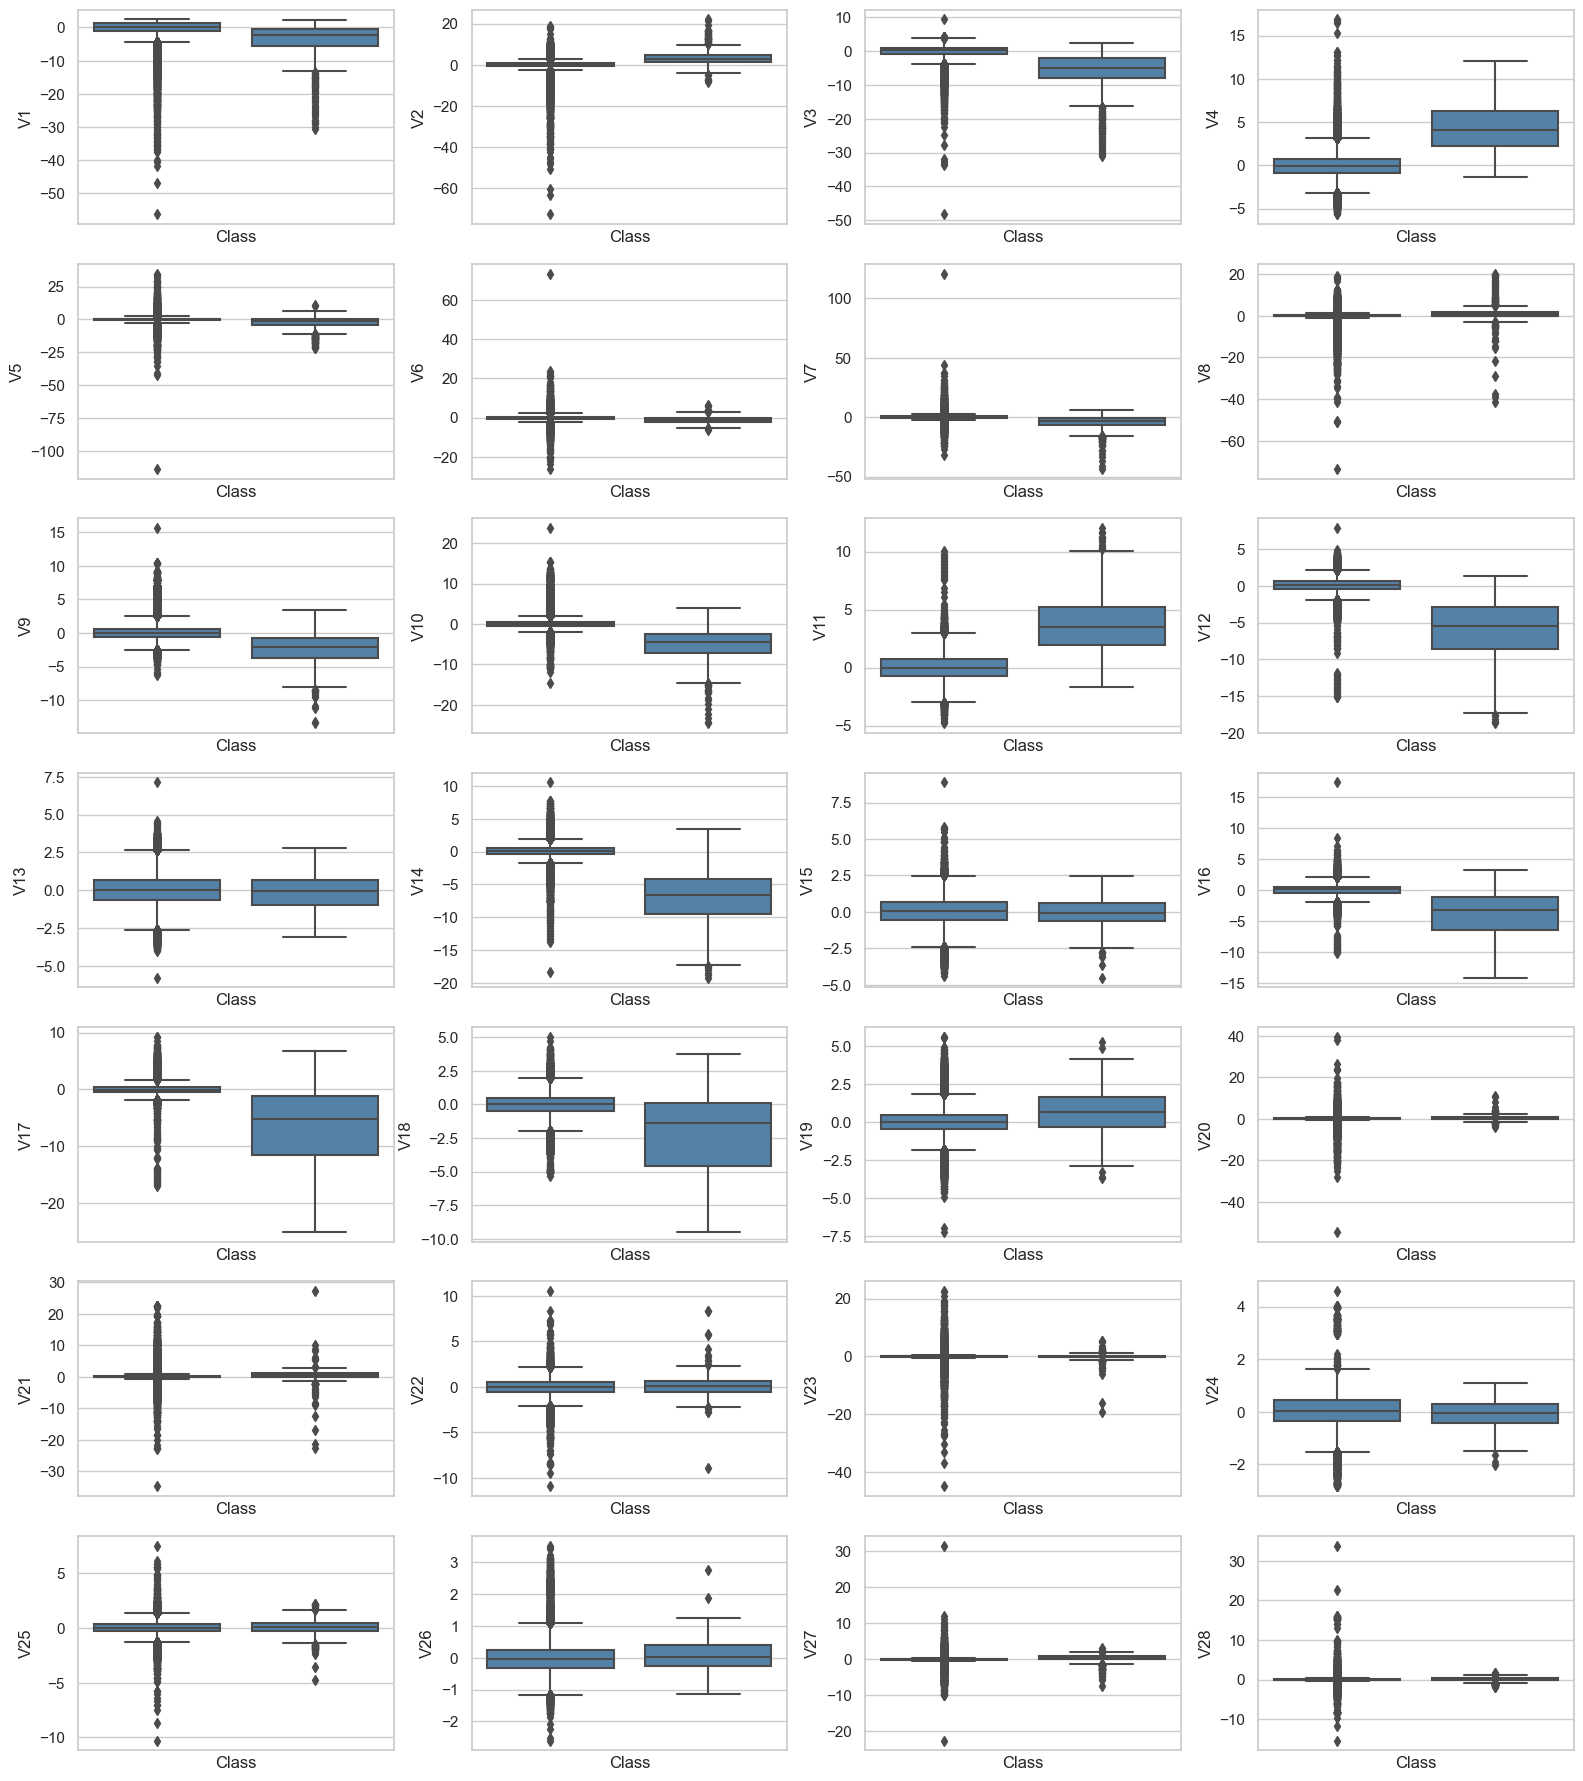

In [33]:
pca_cols = [col for col in df.columns if col.startswith('V')]

plt.figure(figsize=(16, 18))

for i, col in enumerate(pca_cols):
    plt.subplot(7, 4, i+1)  # 7 filas, 4 columnas = 28 espacios
    sns.boxplot(x='Class', y=df[col], data=df, color="steelblue")
    plt.xticks([])
    
plt.tight_layout()
plt.show()

De acuerdo a los gráficos, podemos destacar varias cosas:

- Los boxplots confirman visualmente la separación entre clases. En todas las componentes del grupo 1 se puede observar que no hay solapamiento entre las cajas de Fraude y No Fraude. Esto confirma que estas variables tienen una excelente capacidad discriminante.

- La mediana para todas las componentes en la clase 0 (No fraude) es 0, mientras que en la clase 1 (Fraude) toma valores positivos o negativos según la componente.  

- En todos los gráficos se evidencia una gran cantidad de valores atípicos en ambos grupos, especialmente en el grupo No fraude. Esto es de esperarse debido al fuerte desbalanceo de la base de datos.  

- Las cajas del grupo Fraude son notablamente más altas que las de No fraude, es decir, presentan un mayor rango intercuartílico, y por tanto, una mayor variabilidad en las transacciones fraudulentas. 

In [57]:
display(tabla_variable(df, "Amount"))

,Variable,Grupo,n,Media (SD),Mediana,Q1,Q3,IQR,Min–Max,U,p,RBC
0,Amount,Fraude,473,123.87 (260.21),9.82,1.00,105.89,104.89,0.00–2125.87,59517129.5,2.686e-05,-0.112
1,,No fraude,283253,88.41 (250.38),22.00,5.67,77.46,71.79,0.00–25691.16,,,
2,,Total,283726,88.47 (250.40),22.00,5.60,77.51,71.91,0.00–25691.16,,,


La variable `Amount` presenta una mediana en transacciones fraudulentas de aproximidamente **9.82**, mientras que en transacciones no fraudulentas es de **22**, lo que sugiere que el fraude típico no necesariamente ocurre en transacciones de alto valor. Por otro lado, la media en fraude (123.87) con una desviación estándar de 260.21 es superior a la media en no fraude (88.41) con desviación estándar de 250.38. Sin embargo, esta diferencia en la media podría estar influenciado por la presencia de algunos valores extremos, previamente observados en el boxplot. El rango intercuartílico en transacciones fraudulentas (1 a 105.89) presenta un considerable solapamiento con el rango de las transacciones legítimas (5.67 a 77.46), lo que nos da a entender que no tiene una fuerte capacidad discriminativa, pues muchos de sus valores no permiten distinguir claramente entre fraude y no fraude. Entre las transacciones fraudulentas y no fraudulentas se evidencia una diferencia estadísticamente significativa entre ambos grupos (U = 59517129.5, p ≈ 0.003). El coeficiente de RBC (-0.112) indica que los grupos están muy solapados, no hay diferencia clara entre los dos.

Ahora, haciendo un boxplot de la variable `Amount` divida en las clases de la variables `Class`:

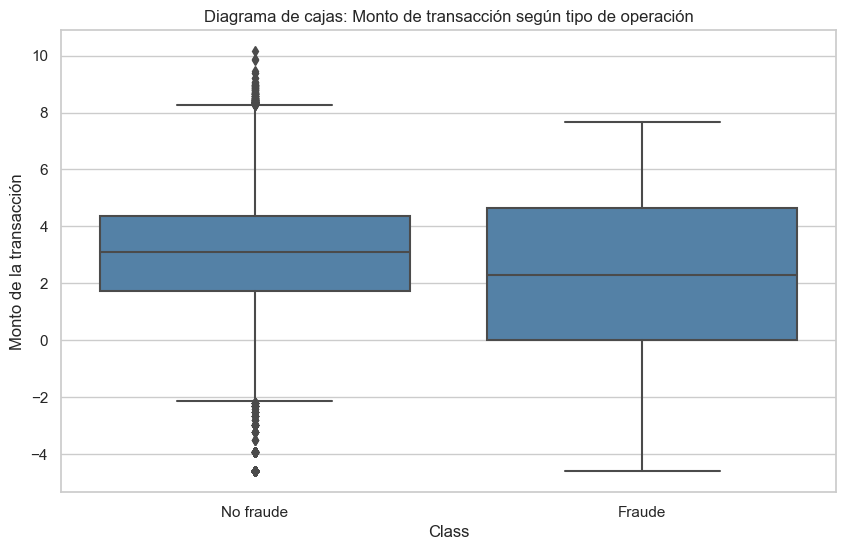

In [35]:
# diagrama de cajas entre fraude y no fraude de la variable amount
plt.figure(figsize=(10, 6))  # Ajustar el tamaño del gráfico

ax= sns.boxplot(x='Class', y=np.log(df['Amount']), data=df, color="steelblue")

# Agregar título y etiquetas
ax.set_xticklabels(["No fraude", "Fraude"])
plt.title('Diagrama de cajas: Monto de transacción según tipo de operación')
plt.ylabel('Monto de la transacción')
# Mostrar el gráfico
plt.show()

Debido a la alta asimetría de la variable `Amount`, se aplicó una transformación logarítmica para visualizar de manera más clara la distribución de los datos. En este caso, se sigue evidenciando que la mediana en las transacciones no fraudulentas es mayor que en la de transacciones fraudulentas. A simple vista, se observa un considerable solapamiento entre ambas cajas, lo que reafirma más que `Amount` no separa fuertemente entre clases. Por otro lado, la clase Fraude parece más disperso hacia valores bajos, mientras que No fraude parece que tiene valores intermedios.

#### **5.3 Análisis multivariado**

##### **5.3.1 Correlación**

Ya que algunas de las variables cuantitativas tienen distribuciones muy sesgadas y colas pesadas, se aplicó el coeficiente de correlación de Spearman, una medida no paramétrica basada en rangos. Este método es más resistente a valores extremos y no necesita asumir normalidad en los datos, como sí lo hace el coeficiente de Pearson. De este modo, se analizan las relaciones monotónica entre las variables sin que la falta de normalidad o los valores atípicos influyan.

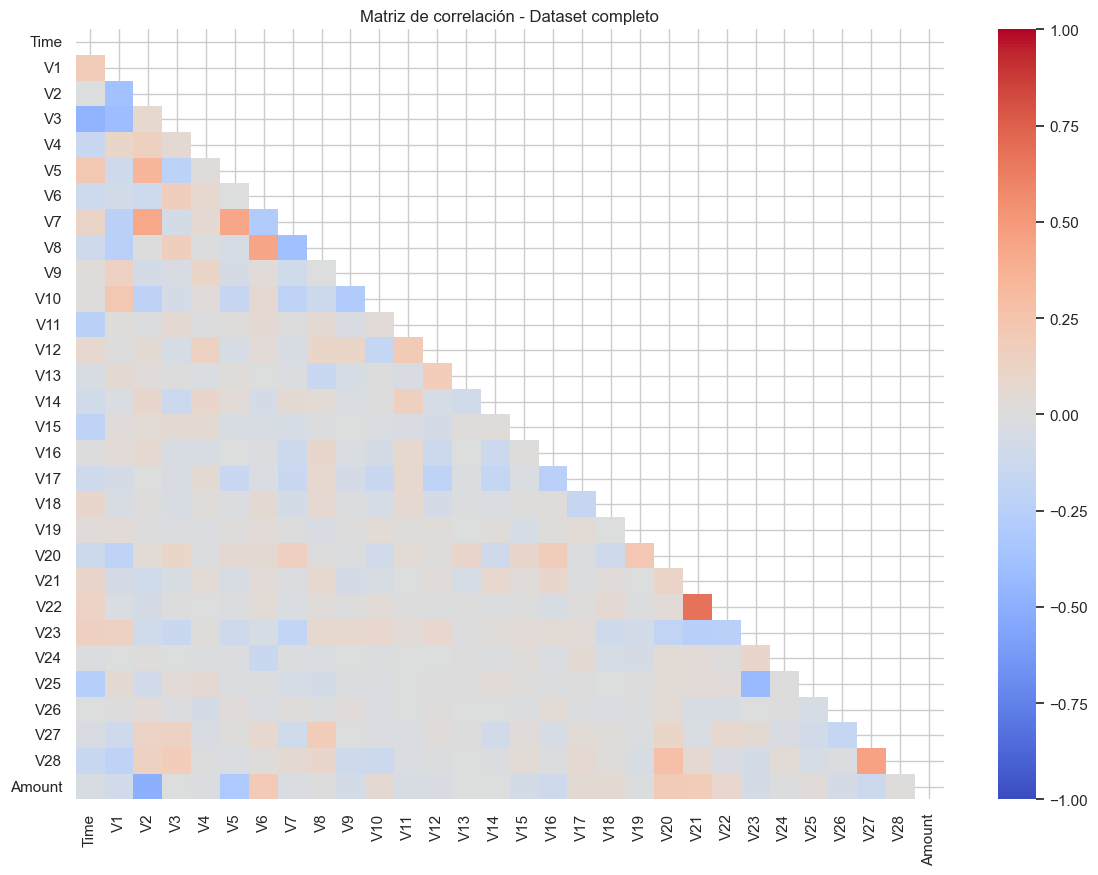

In [37]:
plt.figure(figsize=(14,10))
corr = df.drop("Class", axis=1).corr(method="spearman")
#vamos a crear una máscara para mostrar solo el triángulo inferior de la matriz

#se crea una matriz del mismo tamaño que la matriz de correlación llena de ceros
mask = np.zeros_like(corr) 
#los indices del triángulo superior se ponen a True para ocultarlos
mask[np.triu_indices_from(mask)] = True

sns.heatmap(df.drop("Class", axis=1).corr(method="spearman"),cmap="coolwarm",vmin=-1,vmax=1,mask=mask)

plt.title("Matriz de correlación - Dataset completo")
plt.show()

In [38]:
list_moderada = []
list__alta = []

for i in range(1, 30):
    for j in range(i):
        if abs(corr.iloc[i, j]) >= 0.5 and abs(corr.iloc[i, j]) < 0.7:
            list_moderada.append({
                "Variable 1": corr.columns[i],
                "Variable 2": corr.columns[j],
                "Correlación": corr.iloc[i, j]
            })
df_moderada = pd.DataFrame(list_moderada)  
df_moderada["Clase"] = "No fraude"
df_moderada["Tipo"] = "Moderada"

            
for i in range(1, 30):
    for j in range(i):
        if abs(corr.iloc[i, j]) >= 0.7:
            list__alta.append({
                "Variable 1": corr.columns[i],
                "Variable 2": corr.columns[j],
                "Correlación": corr.iloc[i, j]
            })
df_alta = pd.DataFrame(list__alta)
df_alta["Clase"] = "No fraude"
df_alta["Tipo"] = "Alta"

tabla_corr_general = pd.concat([df_moderada.head(), df_alta.head()], ignore_index=True)
tabla_corr_general = tabla_corr_general[["Clase", "Tipo", "Variable 1", "Variable 2", "Correlación"]]
tabla_corr_general

,Clase,Tipo,Variable 1,Variable 2,Correlación
0,No fraude,Moderada,V22,V21,0.677468
1,No fraude,Moderada,Amount,V2,-0.502958


En este análisis de correlación inicial usando Spearman, muchas de las variables V1-V28 muestran correlaciones bajas entre sí y con las variables Amount y Time, es decir no hay relaciones montónica (no necesariamente lineales) fuertes. No obstante, hay correlaciones visibles como: V21 y V22 tienen una correlación positiva moderada (r = 0.68), mientras que V2 con Amount muestra una correlación negativa moderada (r = -0.50). De todas formas, no se observan patrones de correlación generalizados marcados. Cabe resaltar que la correlación de Pearson, que se sabe que mide la fuerza y dirección de la relación lineal entre dos variables continuas, es aproximadamente 0 entre las variables V1 hasta V28, debido a la ortogonalidad del proceso PCA.  A continuación, se realiza este mismo análisis pero separado por clases.

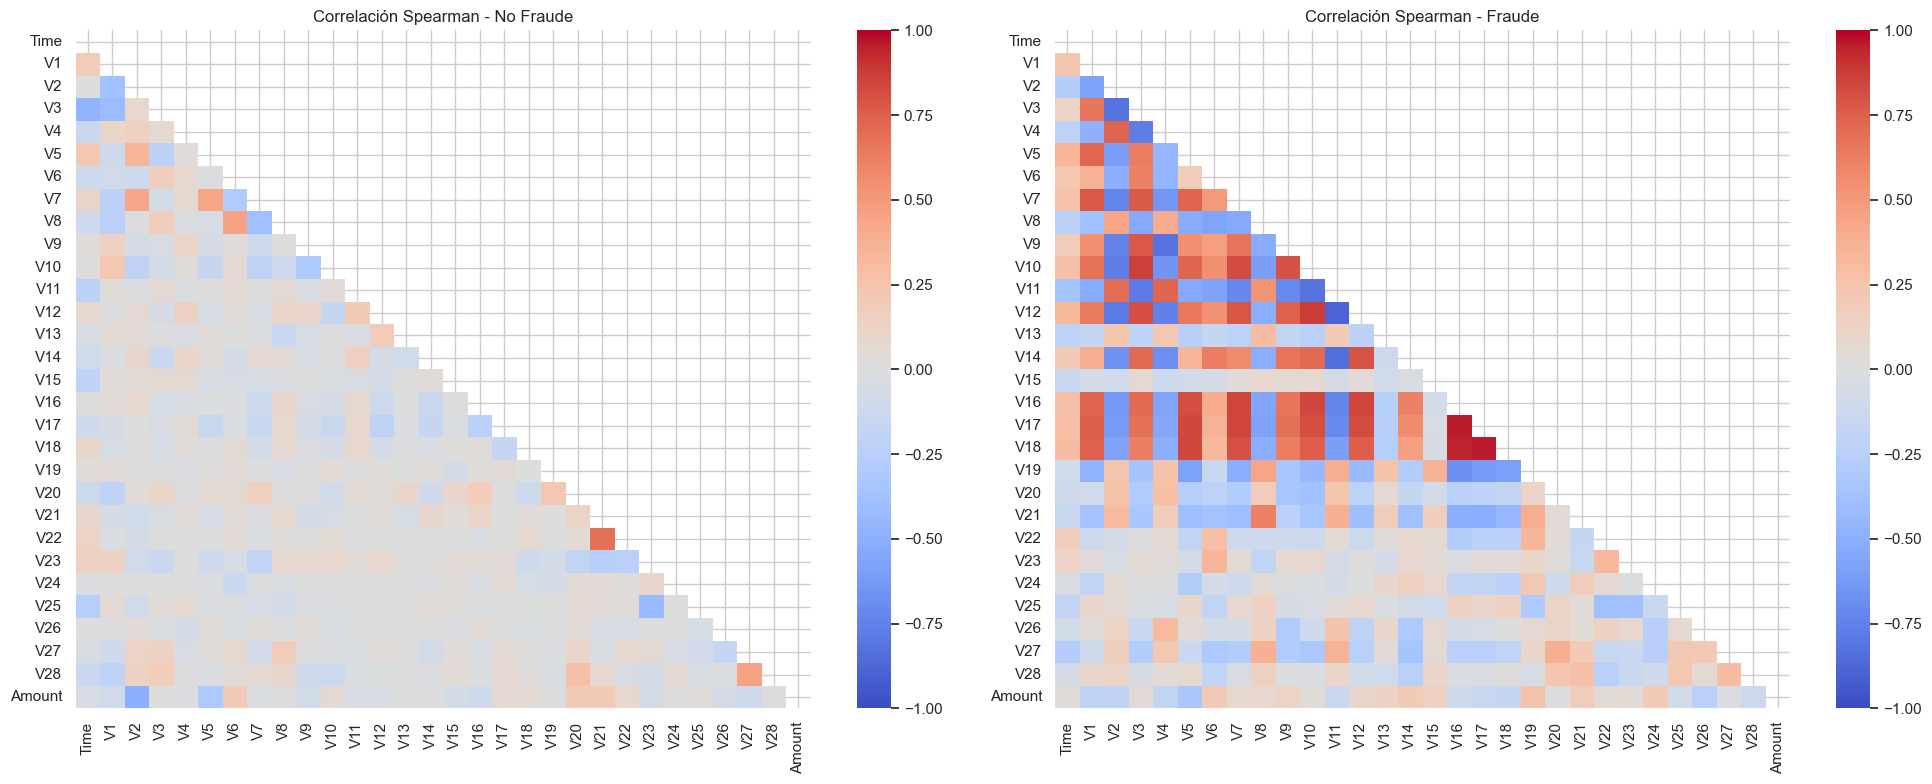

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))  # 1 fila, 2 columnas

corr_no_fraude = no_fraude[columns.drop("Class")].corr(method='spearman')
sns.heatmap(corr_no_fraude, annot=False, cmap='coolwarm', center=0, mask=mask, vmin=-1,vmax=1, ax=axes[0])
axes[0].set_title("Correlación Spearman - No Fraude")

corr_fraude = fraude[columns.drop("Class")].corr(method='spearman')
sns.heatmap(corr_fraude, annot=False, cmap='coolwarm', center=0, mask=mask, vmin=-1,vmax=1, ax=axes[1])
axes[1].set_title("Correlación Spearman - Fraude")

plt.tight_layout()
plt.show()

In [40]:
list_no_fraude_moderada = []
list_no_fraude_alta = []

for i in range(1, 30):
    for j in range(i):
        if abs(corr_no_fraude.iloc[i, j]) >= 0.5 and abs(corr_no_fraude.iloc[i, j]) < 0.7:
            list_no_fraude_moderada.append({
                "Variable 1": corr_no_fraude.columns[i],
                "Variable 2": corr_no_fraude.columns[j],
                "Correlación": corr_no_fraude.iloc[i, j]
            })
df_no_fraude_moderada = pd.DataFrame(list_no_fraude_moderada)  
df_no_fraude_moderada["Clase"] = "No fraude"
df_no_fraude_moderada["Tipo"] = "Moderada"

            
for i in range(1, 30):
    for j in range(i):
        if abs(corr_no_fraude.iloc[i, j]) >= 0.7:
            list_no_fraude_alta.append({
                "Variable 1": corr_no_fraude.columns[i],
                "Variable 2": corr_no_fraude.columns[j],
                "Correlación": corr_no_fraude.iloc[i, j]
            })
df_no_fraude_alta = pd.DataFrame(list_no_fraude_alta)
df_no_fraude_alta["Clase"] = "No fraude"
df_no_fraude_alta["Tipo"] = "Alta"

lista_top5 = []
for i in range(1, 30):
    for j in range(i):
        if abs(corr_fraude.iloc[i, j]) >= 0.7:
            lista_top5.append({
                "Variable 1": corr_fraude.columns[i],
                "Variable 2": corr_fraude.columns[j],
                "Correlación": corr_fraude.iloc[i, j]
            })
df_fraude_alta = pd.DataFrame(lista_top5)
df_fraude_alta["Clase"] = "Fraude"
df_fraude_alta["Tipo"] = "Alta"
            
tabla_correlación = pd.concat([df_no_fraude_moderada.head(), df_no_fraude_alta.head(), df_fraude_alta.head()], ignore_index=True)
tabla_correlación = tabla_correlación[["Clase", "Tipo", "Variable 1", "Variable 2", "Correlación"]]
tabla_correlación



                  

,Clase,Tipo,Variable 1,Variable 2,Correlación
0,No fraude,Moderada,V22,V21,0.679742
1,No fraude,Moderada,Amount,V2,-0.503638
2,Fraude,Alta,V3,V2,-0.822115
3,Fraude,Alta,V4,V2,0.731057
4,Fraude,Alta,V4,V3,-0.766637
5,Fraude,Alta,V5,V1,0.724550
6,Fraude,Alta,V7,V1,0.777459


En el gráfico de correlación de la clase no fraude se observa un patrón muy similar al previamente visto, lo cual es normal debido al fuerte desbalance las correlaciones globales se ven determinadas por la clase del no fraude. Dentro de la clase de las transacciones no fraudulentas no se observa un aumento en el número de correlaciones moderadas y fuertes. Esto nos dice, que en general, dentro de esta clase no hay muchas correlaciones altas o relevantes entre las variables explicativas. Este comportamiento evidencia una cierta homogeneidad, pues dentro de esta clase, las variables no muestran un patrón consistente de subida o bajada conjunta dentro del grupo. 

En la clase de transacciones fraudulentas se observan correlaciones moderadas a fuertes entre las primeras componentes principales (V1-18), con un total de 54 correlaciones fuertes, donde se destacan V18 con V17 (r ≈ 0.96), V17 con V16 (r ≈ 0.96 ) y V18 con V16 (r ≈ 0.94). Por otro lado, Time, Amount y las últimas variables resultantes de PCA (V19-V28) muestran correlaciones bajas. Esto se debe a que las primeras variables capturan la mayor parte de la variabilidad de los datos, por lo que hay más posibilidades de encontrar patrones. Además, en el subconjunto de fraude, al haber pocas observaciones comparado con no fraude, cada diferencia entre valores impacta más la correlación. Siguiendo este orden de ideas, al variar más relativamente entre sí, se generan correlaciones positivas o negativas más fuertes entre las componentes principales (V1-V18). Opuesto a lo que ocurre en la clase no fraude, que se presentan valores muy similares entre sí sin una patron o estructura, lo que genera correlaciones cercanas a 0. 

Luego, este comportamiento evidencia patrones internos consistentes entre estas variables en transacciones fraudulentas. No obstante, estas correlaciones no necesariamente implican que las variables por sí solas diferencien fraude de no fraude, ya que el modelo debe aprender diferencias globales entre ambas clases para predecir correctamente.

##### **5.3.2 Variance Inflation Factor (VIF)**

In [41]:
X = df.drop(columns=['Class']).copy()

# Agregar constante (requerido para statsmodels)
X['Intercept'] = 1

# Calcular VIF
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(31)]

# Eliminar la constante de la tabla final
vif_data = vif_data[vif_data['Variable'] != 'Intercept']

vif_data

,Variable,VIF
0,Time,1.883851
1,V1,1.656669
2,V2,4.467685
3,V3,1.879467
4,V4,1.141301
5,V5,2.866851
6,V6,1.578711
7,V7,2.923828
8,V8,1.134124
9,V9,1.024321


Se calculó el VIF para evaluar la colinealidad entre las variables explicativas. Se observa que las variables V1 a V28 y Time presentan VIF cercanos a 1-5, lo que indica baja colinealidad y que estas aportan información independiente. Es de esperarse que las componentes principales (V1-V28) presenten VIF bajos, pues la ortogonalidad implica que ninguna componente puede predecirse como combinación lineal de las demás, lo que resulta en baja colinealidad. La variable Amount presenta VIF alto (~12), señalando colinealidad con otras variables del dataset. Debido a que las componentes principales V1–V28 ya capturan gran parte de la estructura de los datos, incluir Amount junto con las PCA podría generar redundancia, por lo que para modelos que son sensibles a la colinealidad se considera excluirla o aplicar técnicas de regularización.

### **6. Análisis temporal de las transacciones**

El análisis exploratorio previo permite plantear una pregunta adicional: ¿tienden a concentrarse montos más elevados en ciertos intervalos de tiempo o el comportamiento del monto es independiente del tiempo? Para este análisis se usa la mediana de **Amount** debido al gran sesgo de esta variable.

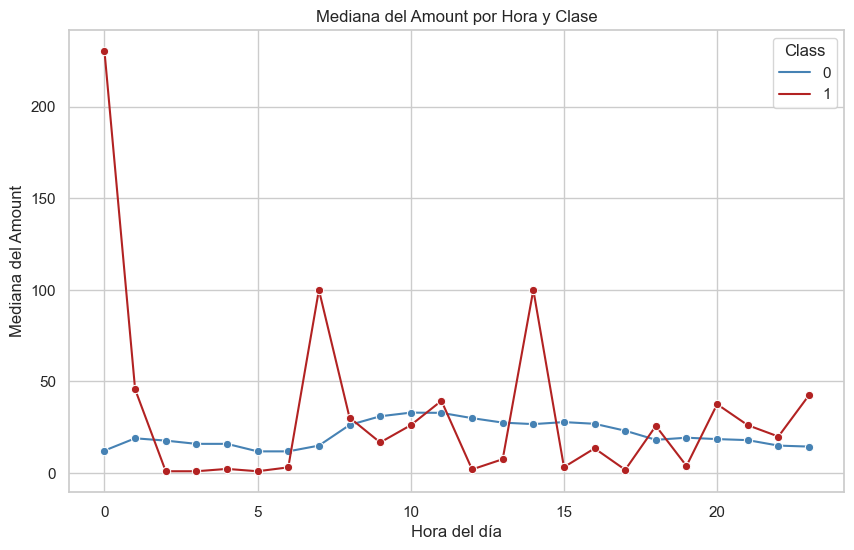

In [44]:
df2=df.copy()
# Crear variable Hour 
df2['Hour'] = (df['Time'] // 3600) % 24

# Calcular mediana por hora y clase
tiempo = df2.groupby(['Hour','Class'])['Amount'].median().reset_index()

# Graficar
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))

sns.lineplot(data=tiempo,x='Hour',y='Amount',hue='Class',palette={"0": "steelblue", "1": "firebrick"},marker="o")

plt.title("Mediana del Amount por Hora y Clase")
plt.xlabel("Hora del día")
plt.ylabel("Mediana del Amount")
plt.legend(title="Class")
plt.show()

A simple vista puede parecer que principalmente a las 12:00 am, las medianas de los montos de las transacciones fraudulentas son muy elevadas. De la misma manera ocurre a las 6:00 am y 2:00pm, sin embargo, no de forma tan extrema. No obstante, las transacciones fraudulentas muestran una alta variabilidad, con picos pronunciados en ciertas horas, lo que implica que estos no siguen un patrón uniforme y pueden concentrarse en intervalos específicos con valores elevados como mencionamos anteriormente. En contraste, el monto en las transacciones no fraudulentas presenta un comportamiento relativamente estable a lo largo del tiempo. 

Aun así, debido al fuerte desbalance presente en la variable objetivo, las fluctuaciones que se observan en la clase fraude podrían estar influenciadas precisamente por el bajo número de observaciones en las horas analizadas. Luego, no es adecuado basar las conclusiones únicamente en la inspección gráfica, por lo que en el futuro se realizaría una prueba estadística formal para evaluar si las diferencias observadas en el tiempo son a causa de un patrón significativo o si pueden atribuirse a variabilidad aleatoria derivada del tamaño muestral reducido en la clase minoritaria.

### **7. Conclusiones**

Este análisis exploratorio muestra que las transacciones fraudulentas y no fraudulentas tienen patrones distintos, aunque con bastante solapamiento en la mayoría de las variablles. Por ejemplo, a pesar de que variables como Time y Amount presenten diferencias estadísticamente significativas, su capacidad para diferenciar entre las clases es baja, gracias a la alta dispersión y superposición de valores entre clases. Por otro lado, en las variables (V1-V28) se identificaron variables con alto, moderado y bajo poder discriminativo, en especial las variables V2, V3, V4, V7, V9, V10, V11, V12, V14, V16 y V17 muestran rangos intercuartílicos separados y un grande tamaño de efecto (RBC > 0.5), por lo que son más útiles para diferenciar entre fraude y no fraude. Siguiendo este orden de ideas, en el EDA se evidencia que las transacciones fraudulentas son más disperas y variables que las no fraudulentas, y que la correlación entre algunas variables (V1-V28) es más fuerte en el grupo fraude, lo que indica ciertos patrones consistentes. Asimismo, las variables PCA tienen baja colinealidad, mientras que Amount es todo lo opuesto, por lo que podría generar redundancia al incluirse en el modelo con estas variables. De manera general, se puede concluir que para el modelado predictivo de fraude es importante agregar las componentes PCA con alto poder discriminativo, en cambio, Time y Amount, aunque son informativas, requieren ser combinadas con otras variables para mejorar su capacidad de clasificación.